# Assess a shrinking lake with ArcGIS Notebooks

In this notebook, you'll use ArcGIS API for Python to assess how Lake Mead in the United States has been shrinking over the years. You'll retrieve several satellite images that form a time series, apply the normalized difference water index (NDWI) to the images, and identify the areas covered with water. You'll then make a graph to show the surface area decrease, map the total shrinkage, and visualize the lake's surface variations over time. In this workflow, you'll also learn how to use Python lists and loops to automate these processes and run them on the entire time series. 

**Note:** This is the fifth notebook in the [Analyze imagery with ArcGIS Notebooks](https://learn.arcgis.com/en/paths/analyze-imagery-with-arcgis-notebooks/) learning path. For an optimal experience, consider doing all five notebooks in the order proposed.

*This notebook was last tested on August 19, 2025.*

## Table of contents

* [Introduction](#introduction)
* [Set up the environment](#environment)
* [Define functions](#functions)
* [Get and prepare the data](#data)
* [Perform the analysis](#analysis)
* [Optional: write more compact code](#stretch)
* [Summary](#summary)
* [Acknowledgments](#acknowledgments)

## Introduction <a class="anchor" id="introduction"></a>

[Lake Mead](https://en.wikipedia.org/wiki/Lake_Mead), located across Nevada and Arizona in the United States, is a reservoir formed by the Hoover Dam. It is an essential source of fresh water in the region. However, for the last few decades, the lake's water level has dropped dramatically due to prolonged drought, increased water demand, and factors [linked to climate change](https://journals.ametsoc.org/view/journals/clim/32/23/jcli-d-19-0207.1.xml). Below is a photo of Lake Mead in October 2021, with the white discoloration showing the past higher water levels.

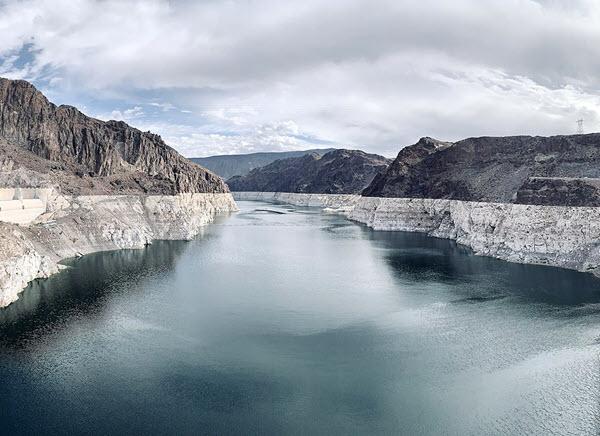

As a GIS analyst for the federal agency that oversees the dam and the lake, you will assess the lake's change over time to inform possible  mitigating and remedial policies. 

## Set up the environment <a class="anchor" id="environment"></a>

First, you need to import the Python modules and functions that you'll use in this notebook and that are not part of Python's default installation. Importing objects and functions makes them available for your code.   

1. Run the cell below to import the required objects and functions.

In [1]:
# Import GIS from the arcgis package - this will allow you to create a GIS object to connect to ArcGIS Online.
from arcgis import GIS

# Import the ImageryLayer class from the arcgis.raster module so you can create imagery layer objects.
from arcgis.raster import ImageryLayer

# Import the apply, clip, nbr, and stretch functions from arcgis.raster.functions so you can apply
# them to the imagery layers.
from arcgis.raster.functions import extract_band, clip, mask, ndwi, stretch, colormap

# Import the polygon class from arcgis.geometry so you can make polygon objects.
from arcgis.geometry import Polygon

# Import the HBox widget from the ipywidgets module so you can compare two maps arranged horizontally beside each other.
from ipywidgets import HBox, Layout

# Import the matplotlib module so you can create a graph.
import matplotlib.pyplot as plt

# Import the polyfit and poly1d functions from numpy, so that you can compute the trendline for your data.
from numpy import polyfit, poly1d

**Tip:** If your notebook remains idle too long at any point in this workflow, it might time out. If that happens or if any step takes longer than a couple of minutes to run (unless indicated otherwise in the notebook), you should restart the kernel. To do that, on the Notebook's ribbon, click **Kernel** and **Restart**. Then run the cells again from the beginning of the notebook.

Next, you'll create a connection to your ArcGIS Online account. This notebook is optimized for running in the ArcGIS Online environment. Since you should already be signed in with your ArcGIS credentials, the Python code can connect directly to your account using the keyword **home**.

2. Run the cell below to create the connection.

In [2]:
# Create the variable gis to hold a home connection to ArcGIS Online.
gis = GIS("home")

## Define functions <a class="anchor" id="functions"></a>

It is best practice to define functions at the beginning of the notebook. You'll define a function to display two images or rasters in side-by-side maps. 

**Note:** In the previous notebooks in the [series](https://learn.arcgis.com/en/paths/analyze-imagery-with-arcgis-notebooks/), the functions were defined just before being used, with the goal of keeping the notebooks as beginner friendly as possible. This current notebook follows slightly more advanced practices. 


3. Run the cell below to define the `side_by_side`
function.

In [3]:
# Define a Python function to display two rasters side by side.
# Function definitions start with the def keyword, followed by open parentheses that include any 
# parameters the function will take, followed by close parentheses, followed by a colon. 
# In this case, the side_by_side function will take two input rasters and an extent as parameters.

def side_by_side(raster_1, raster_2, map_extent):
    """ Method for displaying 2 rasters side by side """
    # The text above in triple quotes is a "docstring", explaining what the function does.
    # The code block that makes up a function is indented four spaces after the first line.
    
    # Make a map.
    map_1 = gis.map()
    # Make a second map.
    map_2 = gis.map()
    
    # Add the first input raster parameter to map 1.
    map_1.content.add(raster_1)
    # Add the second input raster parameter to map 2.
    map_2.content.add(raster_2)
    
    # Set the extent of the maps to be the same as the input map_extent parameter.
    map_1.extent = map_2.extent = map_extent
    
    # Synchronize navigation between the maps.
    map_1.sync_navigation(map_2)

    # Define a layout for each map.
    map_1.layout=Layout(flex='1 1', padding='6px',  width='50%')
    map_2.layout=Layout(flex='1 1', padding='6px',  width='50%')

    # Arrange the two maps in an HBox widget from the ipywidgets Python module.
    box = HBox([map_1, map_2])
    
    # Draw the widget with the two side-by-side maps.
    return box

## Get and prepare the data <a class="anchor" id="data"></a>

You will now set up the data you'll use in this notebook.

### Define your area of interest

Next, to focus the workflow on the right location, you'll define your area of interest (AOI), which contains Lake Mead and a small amount of land around it.

The AOI will be a [polygon](https://developers.arcgis.com/python/guide/part2-working-with-geometries/#Creating-Polygon-objects), defined by latitude and longitude coordinates in the [Web Mercator coordinate system (WKID: 3857)](https://developers.arcgis.com/documentation/spatial-references/#3857---web-mercator).

4. Run the cell below to create a polygon object from a list of coordinates.

In [4]:

# Create a polygon object from a list of 20 coordinates (expressed as 20 longitude and latitude pairs)
# representing the polygon's vertices (or corners). The last one is at the same location as the first to close 
# the polygon.

lake_aoi = Polygon({'rings': [[
    [-12743172.097035687, 4374230.022831326],[-12725071.803005481, 4374230.022831326],[-12723071.805005481, 4360006.698663035],[-12719331.069996325, 4344807.575290244],[-12721820.259512797, 4328901.741333864], 
    [-12711317.205850195, 4322009.771523613],[-12701317.205850195, 4332009.771523613],[-12691317.205850195, 4339009.771523613],[-12684801.732667893, 4327333.862092859],[-12684801.732667893, 4315333.862092859], 
    [-12692511.645262636, 4302874.013041604],[-12716755.433934394, 4294068.471115429],[-12749042.445878882, 4294557.660631901],[-12775948.279835261, 4295046.850148372],[-12789026.969559794, 4308255.172368327], 
    [-12790026.969559794, 4322441.892282608],[-12780351.060129041, 4327204.229597437],[-12760783.183888038, 4336096.199407688],[-12750510.051751064, 4351534.427491887],[-12743172.097035687, 4374230.022831326]]], 
    'spatialReference': {'latestWkid': 3857, 'wkid': 102100}})

# The spatial reference of the polygon is set using the well-known ID or "wkid" code of Web Mercator.


5. Run the cell below to view the polygon in a map.

In [5]:
# Create a variable named map1 that is an instance of the gis.map class.
map1 = gis.map()

# Draw the lake_aoi polygon object on the map.
map1.content.draw(shape=lake_aoi)

# Set the extent of the map to the envelope of the feature.
map1.extent = dict(lake_aoi.envelope)

# Draw the map.
map1

Map(extent={'xmin': -12790026.969559794, 'ymin': 4294068.471115429, 'xmax': -12684801.732667893, 'ymax': 43742…

### Create a list of imagery layers

You will use seven Landsat satellite scenes that were clipped and uploaded in ArcGIS Online. These images were captured between 1998 and 2022, specifically in 1998, 2002, 2006, 2010, 2014, 2018, and 2022. To avoid possible seasonal variations in the lake's water level, the images chosen were all captured in June. The images come from [Landsat 5](https://www.usgs.gov/landsat-missions/landsat-5) and [Landsat 8](https://www.usgs.gov/landsat-missions/landsat-8).

You'll create a time series containing these seven images and you'll visualize them. First, you'll define a list containing the item IDs for these seven images.

**Note:** The ID of an ArcGIS Online item can be found in its URL. For instance, in the URL https://www.arcgis.com/home/item.html?id=886a6e3b4a984df29853d902bd2872e4, the item ID is 886a6e3b4a984df29853d902bd2872e4.

6. Run the cell below to create the list of item IDs.

In [6]:
# Create the lake_imagery_IDs variable, and put in it the list of seven image item IDs.
lake_imagery_IDs = ["886a6e3b4a984df29853d902bd2872e4",
               "9e2a8b58858d49d8a0e493d770f04e6e",
               "bc89cb7a62144b50be16262186c62179",
               "01c47e67052f4d57afc64a86b912ba94",
               "ada7cf13780e41daa359b6d78ec637b8",
               "f85850c020f745b484a3a2e47aa9bc90",
               "11a1b9f4dc484d23bb08097f888f51c9"]

# Show the list you just created.
lake_imagery_IDs

['886a6e3b4a984df29853d902bd2872e4',
 '9e2a8b58858d49d8a0e493d770f04e6e',
 'bc89cb7a62144b50be16262186c62179',
 '01c47e67052f4d57afc64a86b912ba94',
 'ada7cf13780e41daa359b6d78ec637b8',
 'f85850c020f745b484a3a2e47aa9bc90',
 '11a1b9f4dc484d23bb08097f888f51c9']

For easy reference, you will also define a list of the seven years in which these scenes were captured.

7. Run the cell below to create the list of acquisition years.

In [7]:
# Create the years variable and put in it the list of the seven acquisition years.
years = [1998, 2002, 2006, 2010, 2014, 2018, 2022]

# Show the list you just created.
years

[1998, 2002, 2006, 2010, 2014, 2018, 2022]

You will now use a `for` loop to iterate through the seven image item IDs to create an `ImageryLayer` 
instance for each one. You'll put the result in a list to form a time series. 

**Note:** Using a `for` loop avoids having to run the same process seven times. It is powerful, as you could run the same `for` loop on seven, hundreds, or thousands of images. 

8. Run the cell below to create the list of `ImageLayer` instances.

<Item title:"Landsat_Lake_Mead_19980607" type:Tiled Imagery Layer owner:Learn_ArcGIS>
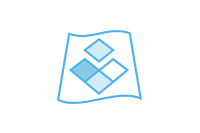

<Item title:"Landsat_Lake_Mead_20020618" type:Tiled Imagery Layer owner:Learn_ArcGIS>
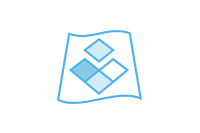

<Item title:"Landsat_Lake_Mead_20060629" type:Tiled Imagery Layer owner:Learn_ArcGIS>
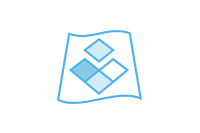

<Item title:"Landsat_Lake_Mead_20100624" type:Tiled Imagery Layer owner:Learn_ArcGIS>
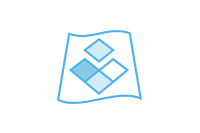

<Item title:"Landsat_Lake_Mead_20140619" type:Tiled Imagery Layer owner:Learn_ArcGIS>
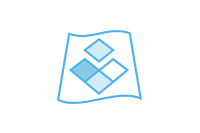

<Item title:"Landsat_Lake_Mead_20180614" type:Tiled Imagery Layer owner:Learn_ArcGIS>
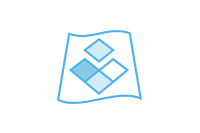

<Item title:"Landsat_Lake_Mead_20220609" type:Tiled Imagery Layer owner:Learn_ArcGIS>
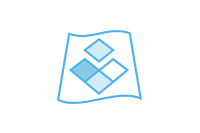

In [8]:
# Use a for loop to iterate through all seven image item IDs and create an ImageryLayer 
# instance for one. And store the result in the lake_imagery_layers list.

# Initialize the lake_imagery_layers list.
lake_imagery_layers = []

# Define the for loop.
for lake_imagery_ID in lake_imagery_IDs:
    # For each image item ID, get the ArcGIS Online item corresponding to the ID using 
    # the gis.content.get function. Store the result in the lake_imagery_layer variable.
    lake_imagery_layer = gis.content.get(lake_imagery_ID)
    # Add (append) the imagery layer you just created to the lake_imagery_layers list.
    lake_imagery_layers.append(lake_imagery_layer)
    
# Display the information about each imagery layer.
for lake_imagery_layer in lake_imagery_layers:
    display(lake_imagery_layer)

The information for the seven imagery layers displays, including a link to their item page in ArcGIS Online. Every image is multispectral and contains six spectral bands:
1. Blue
2. Green
3. Red
4. NIR
5. SWIR 1
6. SWIR 2

### Display the images in natural color

To visualize these images, you'll create natural color composite images, using another `for` loop. This rendering uses the red, green, and blue bands and it is close to what the human eye can see. These are the bands 3, 2, and 1, respectively.

9. Run the cell below to create natural color composite images.

In [9]:
# Use a for loop to iterate through all seven imagery layers to create natural color composite
# images. And store the result in the nat_color_images list.

# Initialize the nat_color_images list.
nat_color_images = []

# Define the for loop.
for lake_imagery_layer in lake_imagery_layers:
    # For each imagery layer, create the composite image with the bands red (3), green (2), 
    # and blue (1), using the extract_band function. Store the result in the nat_color_image
    # variable.
    nat_color_image = extract_band(lake_imagery_layer.layers[0], [3, 2, 1])
    # Append the composite image you just created to the nat_color_images list.
    nat_color_images.append(nat_color_image)
    

You'll display each year followed by the corresponding composite image. 

**Note:** In Python, the elements in a list can be accessed by referring to their position in the list using the square bracket notation and starting the count from 0. So, for instance, `years[0]` will return `1998` and `years[6]` will return `2022`.

You'll use a `for` loop iterating on the range from 0 to 7, and display the year and composite image corresponding to each position. 

10. Run the cell below to display the years and composite images.

1998


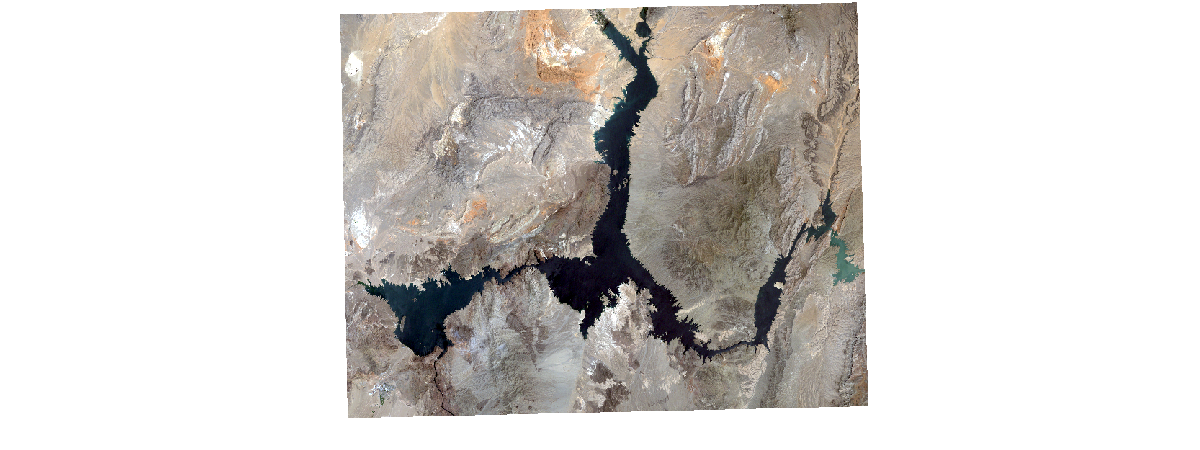

2002


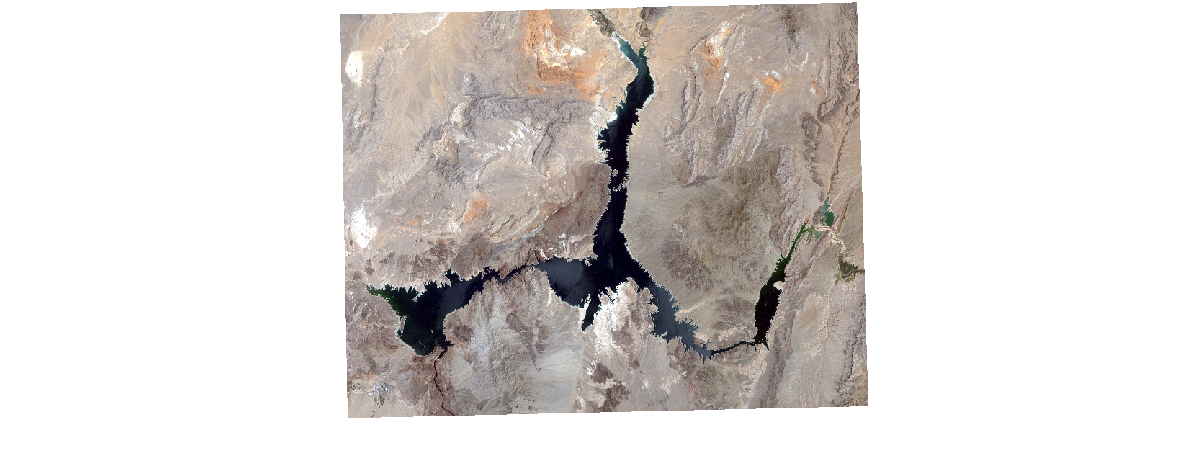

2006


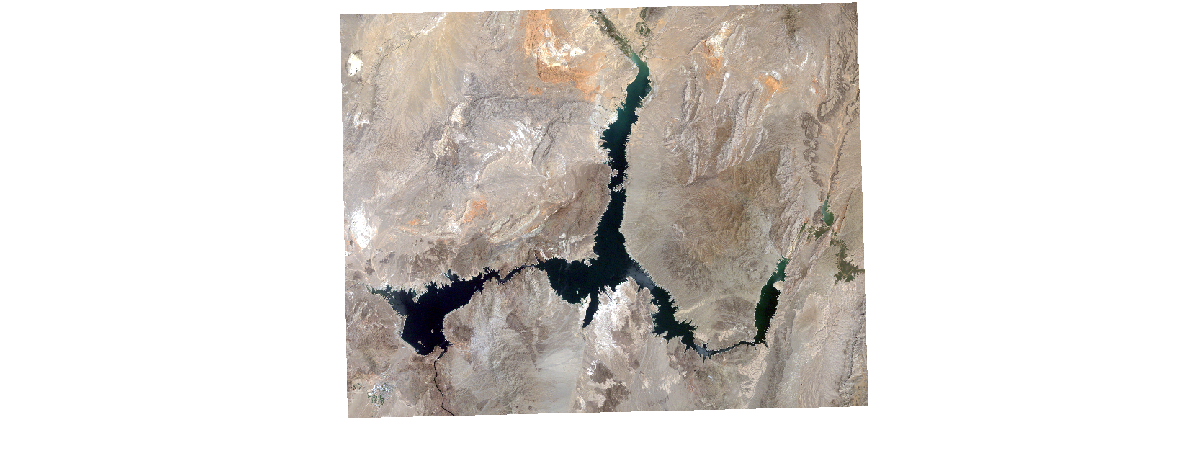

2010


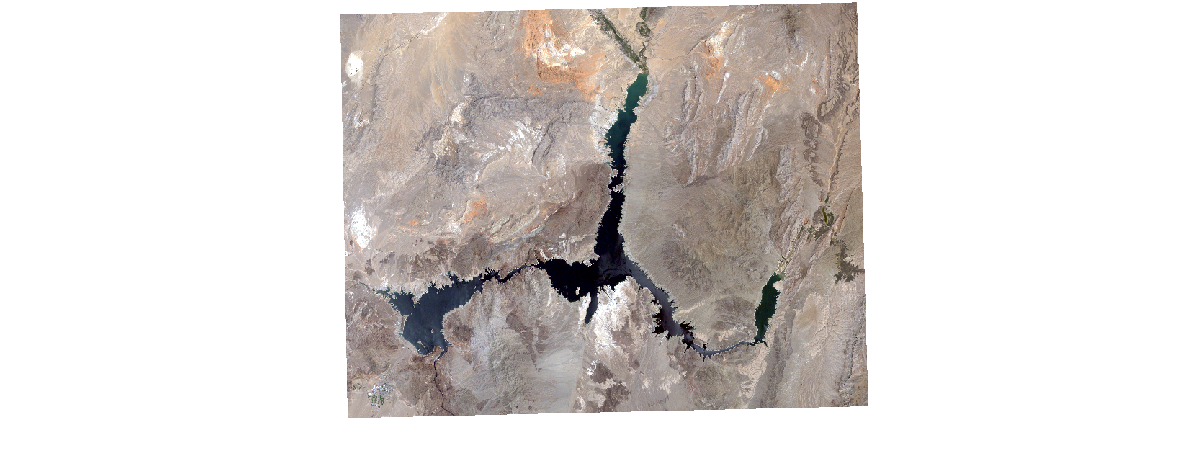

2014


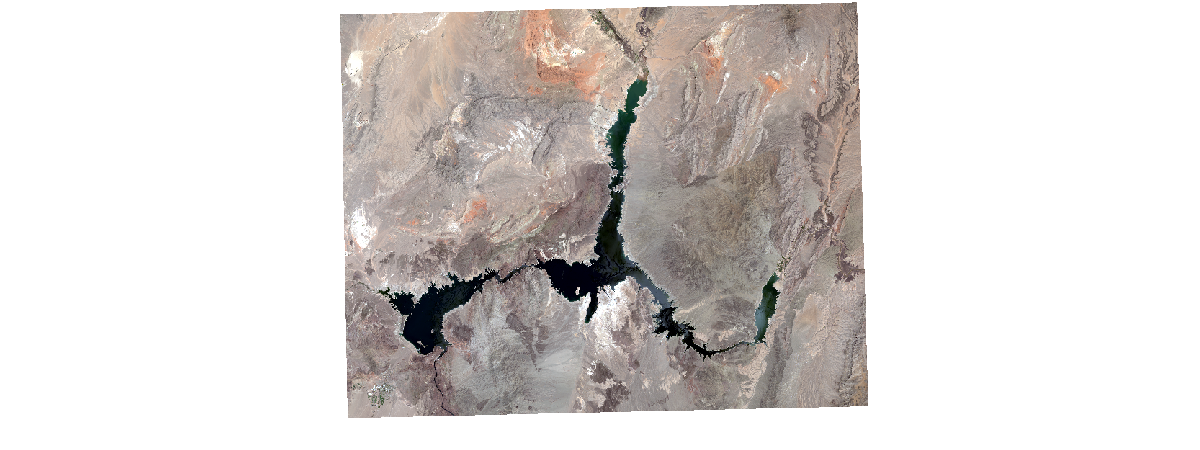

2018


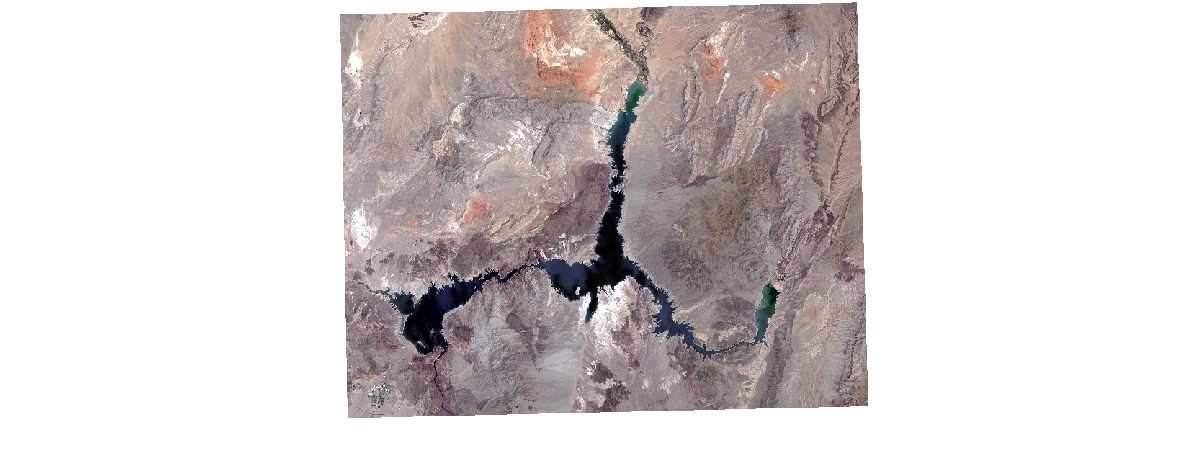

2022


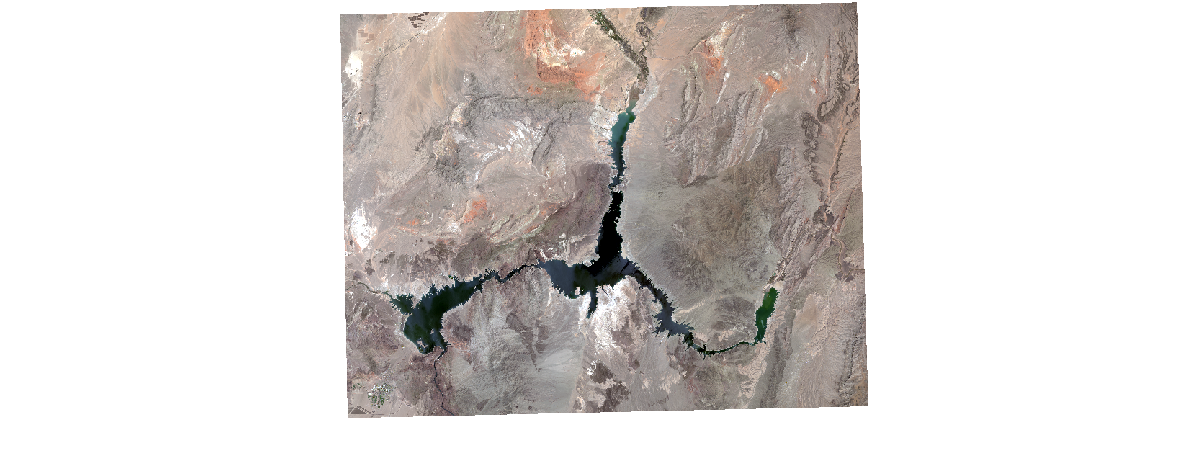

In [10]:
# Use a for loop to iterate on the 0 to 7 and display every year and composite image.

# Define the for loop iterating from 0 to 7 and put that numeric value in the i variable. 
for i in range(0, 7):
    # print the year in position i.
    print (years[i])
    # display the composite image in position i.
    display(nat_color_images[i])

# Note: By convention, the range to go from 0 to n+1, so in this case from 0 to 7 
# (instead of 0 to 6).


After a few moments, all seven images display. On the images, the water is represented in dark blue and black tones and the land around it in beige and brown tones. You can see at a glance that the lake shrank significantly between 1998 and 2022, as its surface seems a bit smaller each year.

Now that you have created and visualized a time series composed of the seven imagery layers, you will proceed to the analysis.

## Perform the analysis <a class="anchor" id="analysis"></a>

In the previous section, you created and visualized the imagery time series and observed Lake Mead's shrinkage visually. You will now perform an analysis to understand more precisely how the lake changed from 1998 to 2022.

### Apply the water index

To better understand how the lake changed, you need to extract the pixels representing water in the seven images and store them into new [raster](https://pro.arcgis.com/en/pro-app/latest/help/data/imagery/introduction-to-raster-data.htm) layers. First, you'll apply the normalized difference water index (NDWI) to every image to highlight the presence of water.  

**Note:** A spectral index uses a mathematical calculation to compute a ratio between different bands for every pixel in an image. The result is a new raster that highlights a specific phenomenon.

NDWI relies on the green and near infrared bands (or bands 2 and 4 in your imagery) and uses the following formula to highlight water:

`(Green - NIR) / (Green + NIR)`


11. Run the cell below to generate NDWI rasters.


In [11]:
# Use a for loop to iterate through the seven imagery layers to generate NDWI rasters.  
# And store the result in the ndwi_layers list.

# Initialize the ndwi_layers list.
ndwi_layers = []

# Define the for loop.
for lake_imagery_layer in lake_imagery_layers:
    # For each image, call the ndwi function. The image and the NIR (4) and Green (2) bands 
    # are passed as parameters. Append the result to the ndwi_layers list.
    ndwi_layers.append(ndwi(lake_imagery_layer.layers[0], band_indexes='4 2'))  
    
#Note: The code in this for loop is written a bit more compactly than before. 
# Instead of storing the result of the ndwi function in an intermediary variable, 
# it is appended directly to the ndwi_layers list.

You could visualize the seven resulting NDWI rasters as you did previously for the natural color composite images. However, this would take some time, so instead, you will only display the first and last rasters in the time series (for 1998 and 2022) as a sample. You'll use the `side-by-side` function you defined earlier. 

12. Run the cell below to display the first and last NDWI rasters in the time series. 

In [12]:
# Display the first and last NDWI rasters using the side-by-side function.
# These correspond to position 0 and 6 in the list. The third argument is the desired extent,
# or AOI for the map.
side_by_side(ndwi_layers[0],
             ndwi_layers[6], 
             dict(lake_aoi.envelope))

After a few moments, the two images display in two maps over the default topographic basemap. You can zoom in and out and drag to pan. Pixels with high NDWI values appear in light tones (light gray and white) and they represent water. Pixels with low NDWI values appear in dark tones (dark gray and black) and represent non-water land cover. 

**Note:** Optionally, you can change the numbers in the cell above and run it again to visualize the other NDWI rasters in the time series.



### Extract the water pixels

From the NDWI rasters, you want to clearly distinguish the pixels that represent water from those that do not. You know that the water pixels have the highest values, so you will look for the pixels that have a value equal or greater to a specific threshold. Knowing that NDWI values can vary from -1 to +1, you'll consider that NDWI values greater than 0 as representing water. 

**Note:** The threshold value of 0 was found by trial and error and might be different for other imagery datasets.

You will create binary rasters that can hold only two possible values: 1 if the NDWI pixel value was above the threshold, 0 if it was below. You can think of these new rasters as answering the question "is this water?" and showing True/False values, where 1 is true and 0 is false.

13. Run the cell below to generate binary water rasters using a `for` loop.

In [13]:
# Use a for loop to iterate through all seven NDWI rasters to generate binary 
# rasters (water/no water), and store the result in the binary_water_rasters list.

# Initialize the water_binary_rasters list.
binary_water_rasters = []

# Define the for loop.
for ndwi_layer in ndwi_layers:
    # For each NDWI raster, keep only the pixels whose value is greater than 0. 
    # Append the resulting binary raster to the binary_water_rasters list.
    binary_water_rasters.append(ndwi_layer > 0)

You'll display the first and last rasters of the binary water raster time series using the `side-by-side` function. You'll apply a [stretch](https://developers.arcgis.com/python/api-reference/arcgis.raster.functions.html#stretch) to every raster to ensure that they display with the 0 and 1 values as black and white. 

14. Run the cell below to display the first and last binary water rasters. 

In [14]:
# Call the side_by_side function to display the first and last binary water rasters 
# in side-by-side maps. For each input raster, apply the MinMax stretch and enable DRA.
side_by_side(stretch(binary_water_rasters[0], stretch_type='MinMax', dra=True),
             stretch(binary_water_rasters[6], stretch_type='MinMax', dra=True), 
             dict(lake_aoi.envelope))

Next, you'll use the `mask` function to keep only the pixels with a value of 1 for each  raster. The other pixels will be turned to Null values. The resulting rasters will only contain the extracted water pixels.

15. Run the cell below to extract the water pixels from the seven binary water rasters.

In [15]:
# Use a for loop to iterate through all seven binary rasters to generate water-only 
# rasters. And store the result in the water_only_rasters list.

# Initialize the water_only_rasters list.
water_only_rasters = []

# Define the for loop.
for binary_water_raster in binary_water_rasters:
    # For each binary water raster, apply the mask function to keep only the pixels 
    # with a value of 1. The other pixels will be set to NULL. Append the resulting raster 
    # to the water_only_rasters list.
    water_only_rasters.append(mask(raster=binary_water_raster, included_ranges=[1,1]))


16. Run the cell below to display the first and last water-only rasters.

In [16]:
# Display the first and last water-only rasters using the side-by-side function.
side_by_side(water_only_rasters[0],
             water_only_rasters[6], 
             dict(lake_aoi.envelope))

**Note:** Remember that the value of the pixels in the water-only rasters can only be 1 or Null. By default, the 1 values are displayed in black.

You have successfully extracted the water pixels from the seven images. 

### Graph the lake's surface area over time

Using the water-only rasters, you will now compute Lake Mead's surface area over time and display the results in a graph. First, you will compute the statistics for every raster in the water-only time series. That includes a `count` of the water pixels (that is, how many water pixels are there in the whole raster?) that you can then use to derive the surface area.

Since every pixel has a spatial resolution of 30 meters by 30 meters, you'll use the following formulas to compute the surface area in square kilometers:
* `surface_in_sq_meters = pixel_count * 30 * 30`
* `surface_in_sq_km = surface_in_sq_meters / 1000000`


17. Run the cell below to compute the number of water pixels in each of the seven water-only rasters for each year in the time series.

**Tip:** This process can take a few moments to run.

In [17]:
# Use a for loop to iterate through all seven water-only rasters to compute the number of water pixel in each raster 
# And store the result in the pixel_count_over_time list.

# Initialize the pixel_count_over_time list.
pixel_count_over_time = []

# Define the for loop.
for water_only_raster in water_only_rasters:
   # For each water-only raster, apply the compute_histograms function to compute 
    # standard histogram statistics including the count of water pixels in the entire raster.
    histogram = water_only_raster.compute_histograms(geometry=lake_aoi, pixel_size="30,30")

    # Put the count value in the pixel_count variable.
    pixel_count = histogram["histograms"][0]["counts"][1]

    # Append the result to the pixel_over_time list.
    pixel_count_over_time.append(pixel_count)

18. Run the cell below to compute the surface area of the lake for each year in the time series.

In [18]:
# Use a for loop to calculate the lake's surface area over time out of the pixel counts collected previously. 
# And store the result in the surface_over_time list.

# Initialize the surface_over_time list.
surface_over_time = []

# Define the for loop.
for pixel_count in pixel_count_over_time:
    # For each pixel count, compute the surface area in square meters.  
    surface_in_sq_meters = pixel_count * 30 * 30
    
    # Convert the surface area to square kilometers.
    surface_in_sq_km = surface_in_sq_meters / 1000000

    # Append the result to the surface_over_time list.
    surface_over_time.append(surface_in_sq_km)

19. Display the surface area value for every year.

In [19]:
# Display the surface area for every year.

# Create a formatted character string for every seven years that will read: 
# 1998: 100 km2 (as an example) 
years_and_areas = "\n".join("{}: {} km2".format(x, y) for x, y in zip(years, surface_over_time))

# Note: This syntax is somewhat advanced and will not be detailed here.

# Print the formatted string.
print(years_and_areas)


1998: 582.7869 km2
2002: 471.528 km2
2006: 406.4004 km2
2010: 339.0048 km2
2014: 334.5102 km2
2018: 322.2162 km2
2022: 276.9777 km2


As expected, the values decrease sharply from year to year, and the area in 2022 was less than half the area in 1998. You will now display the surface area values in a graph. The x-axis will show the years, and the y-axis, the surface areas. You will also add a trend line.

20. Run the cell below to create the surface area graph.

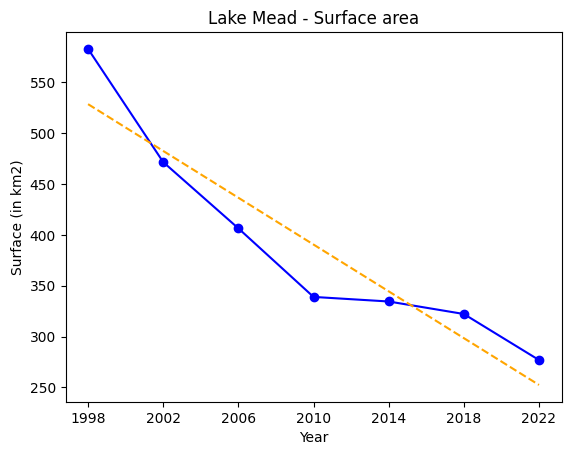

In [20]:
# Create a graph showing Lake Mead's surface area values over time.

# Define the x-axis values (years).
x = years
# Define the y-axis values (surface areas).
y = surface_over_time
  
# Plot the main data line. 
plt.plot(x, y, marker='o', color="blue")

# Make sure every year is spelled out on the x-axis.
plt.xticks(x)
# Name the x-axis.
plt.xlabel('Year')
# Name the y-axis.
plt.ylabel('Surface (in km2)')
# Give a title to the graph.
plt.title('Lake Mead - Surface area')

# Compute the trend line.
z = polyfit(x, y, 1)
p = poly1d(z)
# Add the trend line to the graph.
plt.plot(x,p(x), linestyle = "dashed", color="orange")
  
# Display the graph.
plt.show()

The graph confirms the dramatic decrease in the lake's surface area between 1998 and 2022. 

### Visualize the overall shrinkage

Next, you'll visualize on a map the water surface that was lost between 1998 and 2022.

To do that, you will compute a change raster by subtracting the pixel values from the binary water rasters for 1998 and 2022. Here are the four possible situations:
* If a pixel's value was 1 in 1998 and 0 in 2022, the difference (0 - 1) will be -1. This is the case in which water disappeared at that location.
* If a pixel's value was 1 in 1998 and 1 in 2022, the difference will be 0 (there was water and there is still water).
* If a pixel's value was 0 in 1998 and 0 in 2022, the difference will be 0 (there was no water and there is still no water).
* If a pixel's value was 0 in 1998 and 1 in 2022, the difference (1 - 0) will be 1 (there was no water and now there is water).

You'll then use the mask function to keep only the pixels where the difference result is -1. The resulting raster will show the overall lake shrinkage.

21. Run the cell below to obtain a raster showing the overall lake shrinkage. 

In [21]:
# Put the binary water raster for 1998 in the binary_water_1998 variable.
binary_water_1998 = binary_water_rasters[0]
# Put the water binary raster for 2022 in the binary_water_2022 variable.
binary_water_2022 = binary_water_rasters[6]
# Compute the difference between the two rasters and put the result in the 
# water_difference_1998_2022 variable.
water_difference_1998_2022 = binary_water_2022 - binary_water_1998 

# Use the mask function to keep only the pixels with a value of -1 in 
# the water difference raster. These are the pixels where the lake has dried up. 
# Put the resulting raster in the shrinkage_1998_2022 variable.
shrinkage_1998_2022 = mask(raster=water_difference_1998_2022,
                    included_ranges=[-1,-1])

22. Run the cell below to display the lake shrinkage raster.

In [22]:
# Display the lake shrinkage raster.

# Apply the colormap function to symbolize the dried-up water pixels in a purple color.
# And store the colorized raster in the shrinkage_1998_2022_colorized variable.
shrinkage_1998_2022_colorized = colormap(shrinkage_1998_2022, colormap=[[-1, 157, 86, 245]])
# Note: 157, 86, and 245 represent the RGB values for the purple tone chosen. 
# -1 is the value of the pixels that should be symbolized with this color. 

# Create a variable named map2 that is an instance of the gis.map class.
map2 = gis.map()

# Add the shrinkage_1998_2022_colorized layer to the map. 
map2.content.add(shrinkage_1998_2022_colorized)

# Set the extent of the map to the envelope of AOI.
map2.extent = dict(lake_aoi.envelope)

# Draw the map.
map2

Map(extent={'xmin': -12790026.969559794, 'ymin': 4294068.471115429, 'xmax': -12684801.732667893, 'ymax': 43742…

The map displays. You can zoom in and out to observe the result in more detail. Were some portions of the lake more affected than others?

### Visualize the surface variation over time

You now want to map the shrinkage of the lake over time in more detail. You will compute the number of years in the series during which each pixel was covered with water. 

You'll do that by summing up the seven binary water rasters at the pixel level. As a reminder, possible values for each pixel in these rasters are 1 (water) or 0 (no water). For instance, if a specific pixel was covered with water for 4 years (1998, 2002, 2006, and 2010), and then was not covered with water for 3 years (1014, 2018, and 2022), the result will be 4: 

`1 + 1 + 1 + 1 + 0 + 0 + 0 = 4`

The result will be a raster whose values can vary from 0 to 7:
* 0 -- the pixel was never covered with water.
* 1, 2, 3, 4, 5, or 6 -- the pixel was covered with water some of the years.
* 7 -- the pixel was always covered with water.


23. Run the cell below to sum up the seven rasters using a `for` loop. 

In [23]:
# Sum up all seven binary water rasters.

# Initialize the summed_up_raster variable to 0.
summed_up_raster = 0

# Define the for loop.
for binary_water_raster in binary_water_rasters:
    # Sum up each water binary raster to the summed_up_raster (at the pixel level).
    summed_up_raster += binary_water_raster
    

24. Display the resulting summed-up raster in a map.

In [24]:
# Create a variable named map3 that is an instance of the gis.map class.
map3 = gis.map()

# Apply a stretch to the summed_up_raster layer and add it to the map. 
map3.content.add(stretch(summed_up_raster, stretch_type='MinMax', dra=True))

# Note: The stretch makes sure that the raster displays with the maximum range 
# of tones from black to white.

# Set the extent of the map to the envelope of the AOI.
map3.extent = dict(lake_aoi.envelope)

# Draw the map.
map3

Map(extent={'xmin': -12790026.969559794, 'ymin': 4294068.471115429, 'xmax': -12684801.732667893, 'ymax': 43742…

The raster varies from black (0 -- never covered with water) to white (7 -- always covered with water). 

You'll optimize the display of the raster by removing the 0 values and changing the symbology to a more colorful color ramp.

25. Run the cell below to optimize the display.

In [25]:
# Optimize the display of summed_up_raster.

# Apply the mask function to keep only values 1 to 7 (and discard 0, which means no water).
# And put this value in the water_over_time variable.
water_over_time = mask(raster=summed_up_raster,
                    included_ranges=[1,7])

# Define a custom color ramp that varies from orange to blue. 
custom_colorramp = {
  "type": "algorithmic",
  "fromColor": [237, 164, 28, 255],
  "toColor": [79, 190, 247, 255],
  "algorithm": "esriHSVAlgorithm"
}

# Note: The fromColor and toColor parameters are defined with RGB values followed by an alpha value 
# (that you will keep at the default 255). The algorithm parameter defines how the 
# color ramp will transition between the two colors.

# Apply a stretch to the water_over_time raster, using the custom color ramp you created. 
water_over_time_colorized = stretch(water_over_time, 
                      stretch_type = "MinMax", 
                      dra = True,
                      colorramp = custom_colorramp )


26. Draw a new map with the colorized raster.

In [26]:
# Create a variable named map4 that is an instance of the gis.map class.
map4 = gis.map()

# Add the water_over_time_colorized layer to the map. 
map4.content.add(water_over_time_colorized)

# Set the extent of the map to the envelope of the AOI.
map4.extent = dict(lake_aoi.envelope)

# Draw the map.
map4


Map(extent={'xmin': -12790026.969559794, 'ymin': 4294068.471115429, 'xmax': -12684801.732667893, 'ymax': 43742…

27. Zoom in and pan to examine the result in detail.

You can see in the different sections of the lake how the water has receded and how many years there was water present out of the seven-year time series, based on the following symbology.

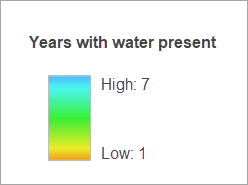


## Optional: Write more compact code <a class="anchor" id="stretch"></a>

Notebooks are great to show a workflow step by step and display intermediary results, as you have seen in this tutorial. However, as you develop longer and more complex workflows, you might want to write code that is a bit less granular. For instance, several of the loops presented earlier in this notebook can be compacted into a single one to go from the imagery item IDs to the extracted water pixel rasters.

28. Run the cell below to apply a several-step process to the list of imagery item IDs. 

In [27]:
# Initialize the list to store all the processed scenes.
water_only_rasters_compact = []

# Use a for loop to iterate over every scene candidate.
for lake_imagery_ID in lake_imagery_IDs:
    lake_imagery_layer = gis.content.get(lake_imagery_ID)
    # Apply the normalized difference water index.
    ndwi_layer = ndwi(lake_imagery_layer.layers[0], band_indexes='4 2') # NIR and Green
    # Generate a binary raster distinguishing water from non-water pixels.
    water_binary_raster = ndwi_layer > 0
    water_only_raster = mask(raster=water_binary_raster,
                    included_ranges=[1,1])
    # Add the resulting raster to the list of processed scenes.
    water_only_rasters_compact.append(water_only_raster)    

29. Run the cell below to display the first and last water-only rasters.

In [28]:
# Display the first and last water-only rasters using the side-by-side function.
side_by_side(water_only_rasters_compact[0],
             water_only_rasters_compact[6], 
             dict(lake_aoi.envelope))

You can write more or less compact code based on the goals and audience of your notebooks. Unless your goal is to teach beginners, you should generally strive for a happy medium in which the workflow is easy to follow but you might not display every possible intermediate results.


## Summary <a class="anchor" id="summary"></a>

In this notebook, you used ArcGIS API for Python to assess how Lake Mead has been shrinking over the years. You retrieved several satellite images that form a time series, applied the normalized difference water index (NDWI) to the images, and identified the areas covered with water. You then made a graph to show the surface area decrease, mapped the total shrinkage, and visualized the lake's surface variations over time. You also learned how to use Python lists and loops to automate these processes and run them on the entire time series. 

You can find other notebooks like this one in the [Analyze imagery with ArcGIS Notebooks](https://learn.arcgis.com/en/paths/analyze-imagery-with-arcgis-notebooks/) learning path. 

For more information about remote sensing in ArcGIS, see also the [Introduction to Imagery and Remote Sensing](https://introduction-to-remote-sensing-learngis.hub.arcgis.com/) curriculum. For more information about Python and ArcGIS, see [Learn Python with ArcGIS Notebooks](https://learn.arcgis.com/en/paths/learn-python-with-arcgis-notebooks/) and [Learn Python in ArcGIS Pro](https://learn.arcgis.com/en/paths/learn-python-in-arcgis-pro/).

## Acknowledgments <a class="anchor" id="acknowledgments"></a>

Author: Delphine Khanna, principal product engineer at Esri.

Thank you to Professor Karen Schuckman, Pennsylvania State University, for her invaluable help.

Data credit: Landsat images courtesy of the U.S. Geological Survey.

Image credit: Lake Mead photo by APK on [Wikimedia Common](https://commons.wikimedia.org/wiki/File:Water_intake_towers_at_Hoover_Dam.jpg).

If you experience any issues with this notebook, contact <LearnArcGISSupport@esri.com>.